In [1]:
from __future__ import annotations

In [2]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>'))

In [3]:
import os
import datetime
import numpy as np
import sklearn.metrics
import tensorflow as tf
import sklearn.datasets
import matplotlib.pyplot as plt
import keras
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path

import seaborn as sns
sns.set_style('dark')
sns.set(rc={'figure.figsize': (10, 10), 'axes.grid': False})

In [4]:
rng = np.random.default_rng()

In [5]:
def plot_grid_and_label_(X, y, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, label_description=None, gray=False):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]

    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])

    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            if gray:
                ax[i, j].imshow(imgs[i, j], cmap="gray")
            else:
                ax[i, j].imshow(imgs[i, j])
            ax[i, j].set_title(map_label(labels[i, j]))
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [6]:
def plot_grid_and_label(X, y, model, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, flatten_image=True, label_description=None, gray=False):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]
    inputs = imgs.reshape(-1, *imgs.shape[2:])

    if flatten_image:
        inputs = inputs.reshape(nrows * ncols, -1)

    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])

    preds = np.argmax(tf.nn.softmax(model.predict(inputs)), axis=-1).reshape(nrows, ncols)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            ax[i, j].set_title(f'label: {map_label(labels[i, j])}, prediction: {map_label(preds[i, j])}')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [7]:
label_description = [
     'A',   'I',   'U',  'E',  'O',
    'KA',  'KI',  'KU', 'KE', 'KO',
    'SA', 'SHI',  'SU', 'SE', 'SO',
    'TA', 'CHI', 'TSU', 'TE', 'TO',
    'NA',  'NI',  'NU', 'NE', 'NO',
    'HA',  'HI',  'FU', 'HE', 'HO',
    'MA',  'MI',  'MU', 'ME', 'MO',
    'YA',         'YU',       'YO',
    'RA',  'RI',  'RU', 'RE', 'RO',
    'WA',  'II',        'EE', 'WO',
     'N',  'IT'
]

In [8]:
X, y = sklearn.datasets.fetch_openml('Kuzushiji-49', version=1, return_X_y=True, as_frame=False, parser='auto')
y = np.array(list(map(int, y)))
X_train, X_test, y_train, y_test = train_test_split(X, y)

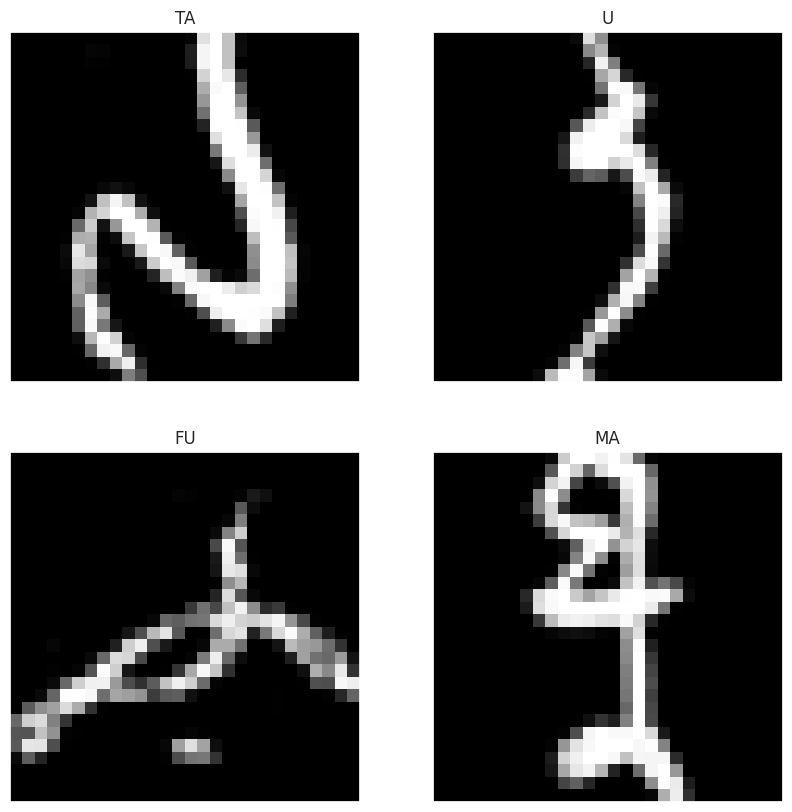

In [9]:
plot_grid_and_label_(X.reshape(-1, 28, 28, 1), y, label_description=label_description, gray=True)

In [10]:
counts = { j: np.sum(y_train == i) for i, j in enumerate(label_description) }

In [11]:
counts # what to do with imbalanced classes?

{'A': np.int64(5293),
 'I': np.int64(5238),
 'U': np.int64(5203),
 'E': np.int64(680),
 'O': np.int64(5276),
 'KA': np.int64(5216),
 'KI': np.int64(5270),
 'KU': np.int64(5203),
 'KE': np.int64(4149),
 'KO': np.int64(5267),
 'SA': np.int64(5297),
 'SHI': np.int64(5166),
 'SU': np.int64(5251),
 'SE': np.int64(3688),
 'SO': np.int64(3391),
 'TA': np.int64(5276),
 'CHI': np.int64(2257),
 'TSU': np.int64(5226),
 'TE': np.int64(5257),
 'TO': np.int64(5230),
 'NA': np.int64(5230),
 'NI': np.int64(5233),
 'NU': np.int64(1785),
 'NE': np.int64(2176),
 'NO': np.int64(5238),
 'HA': np.int64(5253),
 'HI': np.int64(4452),
 'FU': np.int64(5252),
 'HE': np.int64(5318),
 'HO': np.int64(1732),
 'MA': np.int64(5240),
 'MI': np.int64(2674),
 'MU': np.int64(1531),
 'ME': np.int64(3008),
 'MO': np.int64(5252),
 'YA': np.int64(5208),
 'YU': np.int64(1358),
 'YO': np.int64(5268),
 'RA': np.int64(5258),
 'RI': np.int64(5256),
 'RU': np.int64(5262),
 'RE': np.int64(5216),
 'RO': np.int64(1877),
 'WA': np.int6

Для решения проблемы дисбаланса классов посчитаю веса каждого класса

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.25, random_state=47)

In [13]:
class_weights = compute_class_weight("balanced", classes=np.unique(y), y=Y_train)
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(0.7869827756496411),
 1: np.float64(0.7871321649388685),
 2: np.float64(0.7893798296017436),
 3: np.float64(6.29227958254622),
 4: np.float64(0.7971188475390156),
 5: np.float64(0.7913382146751831),
 6: np.float64(0.7896804884589524),
 7: np.float64(0.7880296930630861),
 8: np.float64(0.9970214582587063),
 9: np.float64(0.7986541303732587),
 10: np.float64(0.7923967599652129),
 11: np.float64(0.7898309037900875),
 12: np.float64(0.7881794801174604),
 13: np.float64(1.1515168688969617),
 14: np.float64(1.2396449162624692),
 15: np.float64(0.7937619151795481),
 16: np.float64(1.842938775510204),
 17: np.float64(0.7872816109546154),
 18: np.float64(0.7890793995999922),
 19: np.float64(0.7902824937865369),
 20: np.float64(0.7854919956237847),
 21: np.float64(0.7968124990195925),
 22: np.float64(2.272116298574224),
 23: np.float64(1.944028244209076),
 24: np.float64(0.7862366789719301),
 25: np.float64(0.7948269589606975),
 26: np.float64(0.9177981949752012),
 27: np.float64(

In [14]:
28 * 28

784

In [15]:
# create model, this model should accept a flattened image
shape = 512
layer_name = 0

inputs_ = x_ = y_ = keras.layers.Input(shape=(784,), dtype="int64", name="inputs")

for i in range(5):
    x_ = keras.layers.Dense(shape, name=f"dense_x_{layer_name}")(x_)
    x_ = keras.layers.BatchNormalization(name=f"bn_x_{layer_name}")(x_)
    x_ = keras.layers.Activation("swish", name=f"act_x_{layer_name}")(x_)
    y_ = keras.layers.Dense(shape, name=f"dense_y_{layer_name}")(y_)
    y_ = keras.layers.BatchNormalization(name=f"bn_y_{layer_name}")(y_)
    y_ = keras.layers.Activation("relu", name=f"act_y_{layer_name}")(y_)
    shape //= 2
    layer_name += 1

x_ = keras.layers.Concatenate()([x_, y_])
x_ = keras.layers.Dense(49, activation="softmax", name="output")(x_)
model = keras.models.Model(inputs=inputs_, outputs=x_, name="model")

In [16]:
model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, 784)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_x_0 (Dense)   │ (None, 512)       │    401,920 │ inputs[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_y_0 (Dense)   │ (None, 512)       │    401,920 │ inputs[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_x_0              │ (None, 512)       │      2,048 │ dense_x_0[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_y_0              │ (None, 512)       │      2,048 │ dense_y_0[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_x_0             │ (None, 512)       │          0 │ bn_x_0[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_y_0             │ (None, 512)       │          0 │ bn_y_0[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_x_1 (Dense)   │ (None, 256)       │    131,328 │ act_x_0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_y_1 (Dense)   │ (None, 256)       │    131,328 │ act_y_0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_x_1              │ (None, 256)       │      1,024 │ dense_x_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_y_1              │ (None, 256)       │      1,024 │ dense_y_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_x_1             │ (None, 256)       │          0 │ bn_x_1[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_y_1             │ (None, 256)       │          0 │ bn_y_1[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_x_2 (Dense)   │ (None, 128)       │     32,896 │ act_x_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_y_2 (Dense)   │ (None, 128)       │     32,896 │ act_y_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_x_2              │ (None, 128)       │        512 │ dense_x_2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_y_2              │ (None, 128)       │        512 │ dense_y_2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_x_2             │ (None, 128)       │          0 │ bn_x_2[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_y_2             │ (None, 128)       │          0 │ bn_y_2[0][0]      │
│ (Activation)        │                   │            │                 

 Total params: 1,164,081 (4.44 MB)

 Trainable params: 1,160,113 (4.43 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [ ]:
# compile the model
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
# train the model
model.fit(X_train, Y_train, batch_size=64, validation_data=(X_test, Y_test), epochs=1000,
    callbacks=[
        keras.callbacks.ModelCheckpoint(str(Path("kuzushiji-49") / "models" / "model_kuzushiji_float.keras"), save_best_only=True, monitor='val_loss', mode="min"),
        keras.callbacks.ReduceLROnPlateau("val_loss", factor=0.5, patience=5, mode="min", min_delta=0.001, min_lr=0.0001),
    ],
class_weight=class_weights,
)

Epoch 1/1000
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.6632 - loss: 1.3875 - val_accuracy: 0.8508 - val_loss: 0.5507 - learning_rate: 0.0010
Epoch 2/1000
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.8537 - loss: 0.5057 - val_accuracy: 0.8786 - val_loss: 0.4425 - learning_rate: 0.0010
Epoch 3/1000
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8873 - loss: 0.3744 - val_accuracy: 0.8987 - val_loss: 0.3719 - learning_rate: 0.0010
Epoch 4/1000
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9076 - loss: 0.2939 - val_accuracy: 0.9011 - val_loss: 0.3616 - learning_rate: 0.0010
Epoch 5/1000
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9232 - loss: 0.2424 - val_accuracy: 0.9095 - val_loss: 0.3315 - learning_rate: 0.0010
Epoch 6/1000
 276/3175 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9393 - loss: 0.1885

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


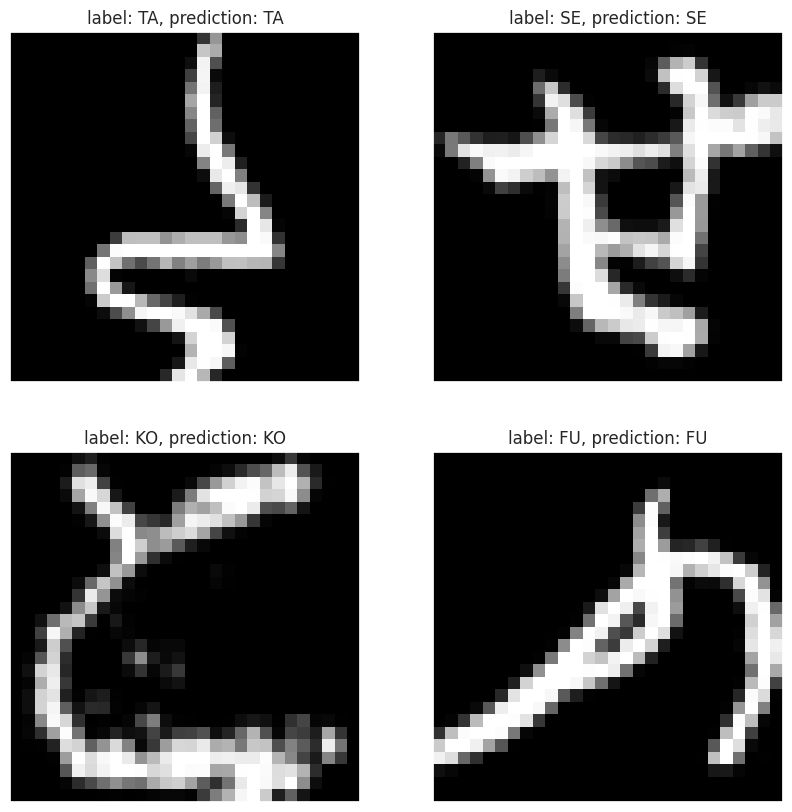

In [19]:
plot_grid_and_label(X_test.reshape(-1, 28, 28, 1), Y_test, model, label_description=label_description)

In [20]:
y_pred = model.predict(X_test, batch_size=64)
y_pred = np.argmax(y_pred, axis=-1)

1059/1059 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


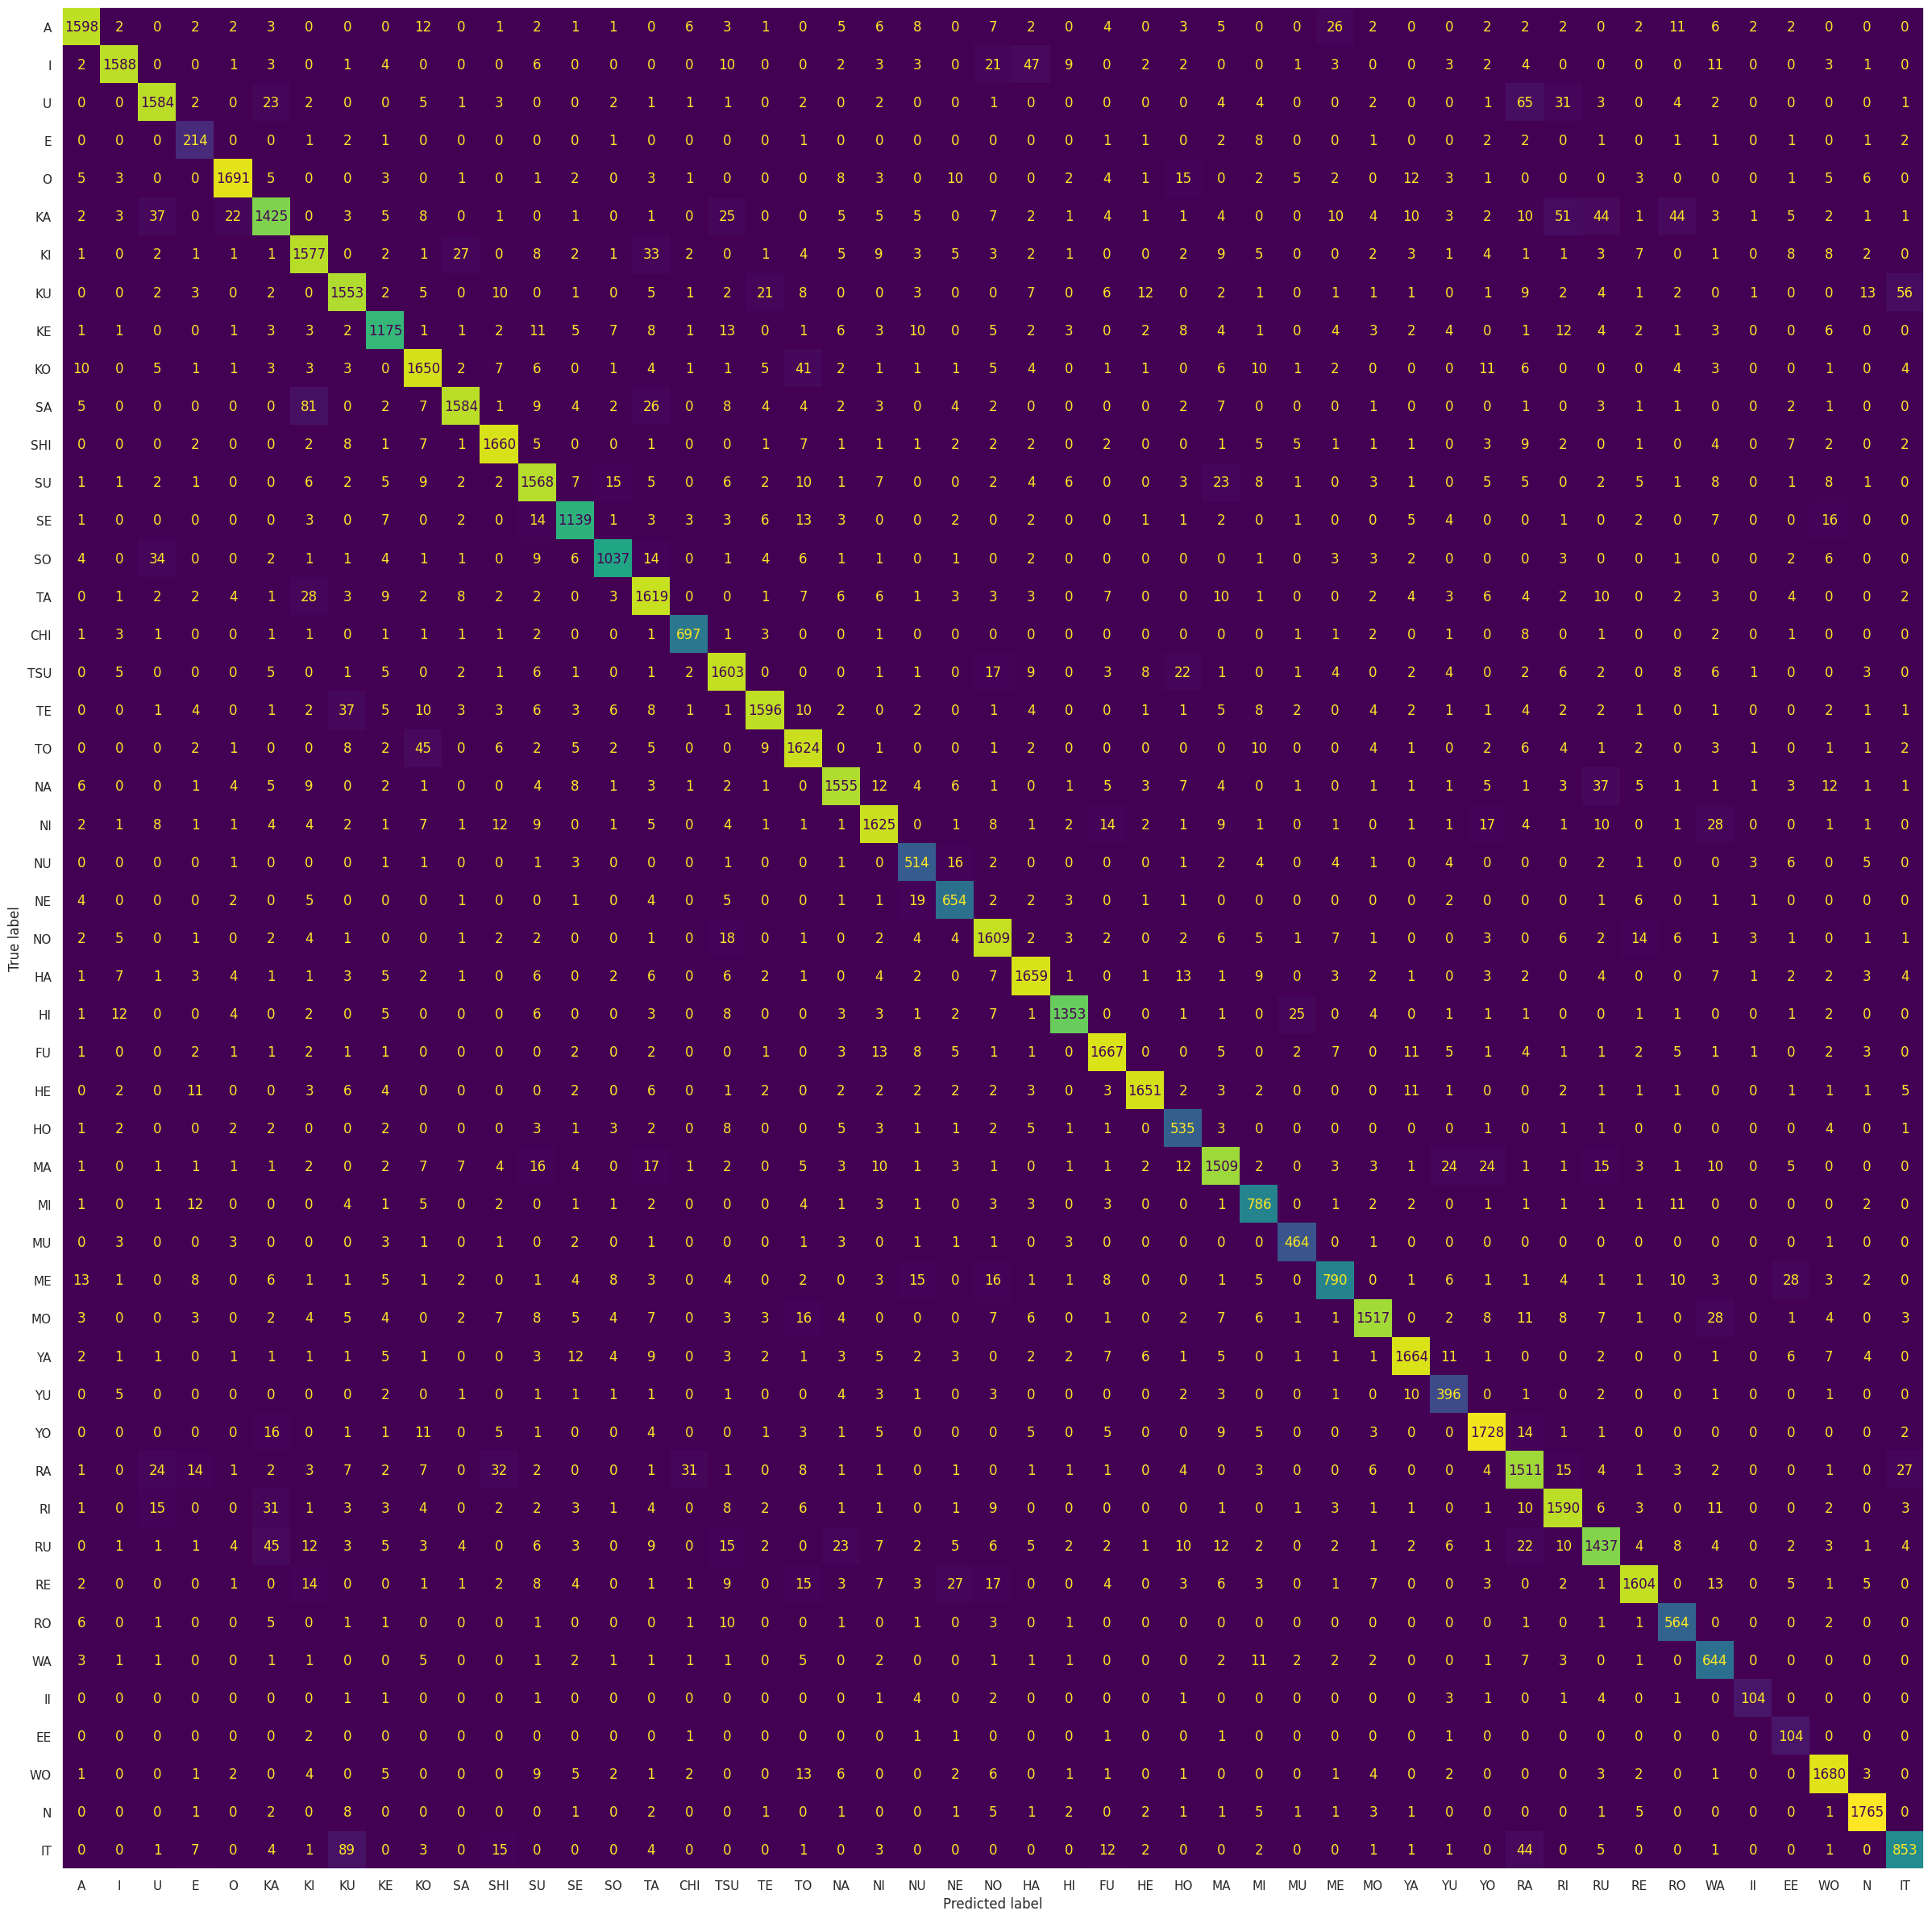

In [21]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(Y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [22]:
accuracy = Y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.9110650152523685)

In [23]:
# create train and validation datasets, these datasets should use 28x28x1 images
X_conv2d_train = X_train.reshape(-1, 28, 28, 1)
X_conv2d_test = X_test.reshape(-1, 28, 28, 1)

In [24]:
# create model, this model should accept a 28x28x1 image
features = 8
name_ctr = 0

inputs_ = x_ = keras.layers.Input(shape=(28, 28, 1), dtype="float32", name="inputs")

for i in range(3):
    x_ = keras.layers.Conv2D(features, kernel_size=5, padding="same", name=f"conv_{name_ctr}")(x_)
    x_ = keras.layers.BatchNormalization(name=f"batch_n_{name_ctr}")(x_)
    x_ = keras.layers.Activation("relu", name=f"activation_{name_ctr}")(x_)
    x_ = keras.layers.Dropout(0.2, name=f"dropout_{name_ctr}")(x_)

    features *= 2
    name_ctr +=1

x_ = keras.layers.MaxPooling2D(2, name="max_pool")(x_)

for i in range(2):
    x_ = keras.layers.Conv2D(features, kernel_size=3, padding="valid", name=f"conv_{name_ctr}")(x_)
    x_ = keras.layers.BatchNormalization(name=f"batch_n_{name_ctr}")(x_)
    x_ = keras.layers.Activation("relu", name=f"activation_{name_ctr}")(x_)
    x_ = keras.layers.Dropout(0.2, name=f"dropout_{name_ctr}")(x_)

    features *= 2
    name_ctr +=1

x_ = keras.layers.Flatten(name="flatten")(x_)
x_ = keras.layers.Dense(49, activation="softmax", name="output")(x_)

model_conv2d = keras.models.Model(inputs=inputs_, outputs=x_, name="model_conv2d")

In [25]:
model_conv2d.summary()

Model: "model_conv2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0 (Conv2D)                 │ (None, 28, 28, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_n_0 (BatchNormalization)  │ (None, 28, 28, 8)      │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_0 (Activation)       │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 28, 28, 16)     │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_n_1 (BatchNormalization)  │ (None, 28, 28, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 28, 28, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_n_2 (BatchNormalization)  │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool (MaxPooling2D)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_n_3 (BatchNormalization)  │ (None, 12, 12, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_n_4 (BatchNormalization)  │ (None, 10, 10, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 49)             │       627,249 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 736,849 (2.81 MB)

 Trainable params: 736,353 (2.81 MB)

 Non-trainable params: 496 (1.94 KB)

In [ ]:
# compile the model
model_conv2d.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
# train the model
model_conv2d.fit(X_conv2d_train, Y_train, batch_size=64, validation_data=(X_conv2d_test, Y_test), epochs=100,
    callbacks=[
        keras.callbacks.ModelCheckpoint(str(Path("kuzushiji-49") / "models" / "model_kuzushiji_conv.keras"), save_best_only=True, monitor='val_loss', mode="min"),
        keras.callbacks.ReduceLROnPlateau("val_loss", factor=0.5, patience=5, mode="min", min_delta=0.001, min_lr=0.0001),
    ],
    class_weight=class_weights
)

Epoch 1/100
3175/3175 ━━━━━━━━━━━━━━━━━━━━ 45s 11ms/step - accuracy: 0.7412 - loss: 1.1018 - val_accuracy: 0.9154 - val_loss: 0.2973 - learning_rate: 0.0010
Epoch 2/100


KeyboardInterrupt: 

In [28]:
images = X_conv2d_test.reshape(-1, 28, 28, 1) # normalize if needed

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step


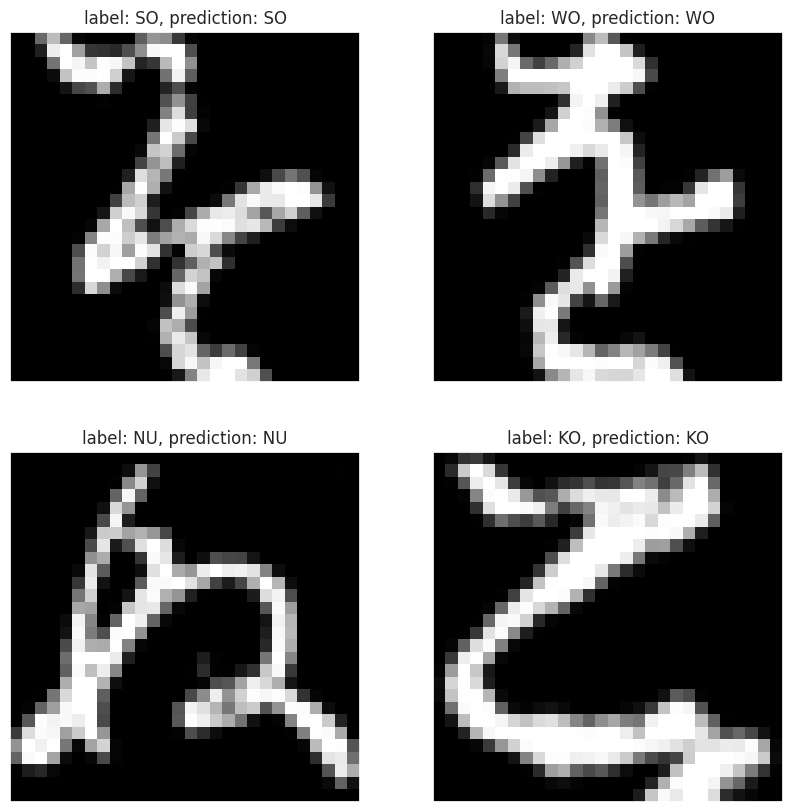

In [29]:
plot_grid_and_label(images, Y_test, model_conv2d, label_description=label_description, flatten_image=False)

In [30]:
y_conv2d_pred = model_conv2d.predict(X_conv2d_test, batch_size=64)
y_conv2d_pred = np.argmax(y_conv2d_pred, axis=-1)

1059/1059 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


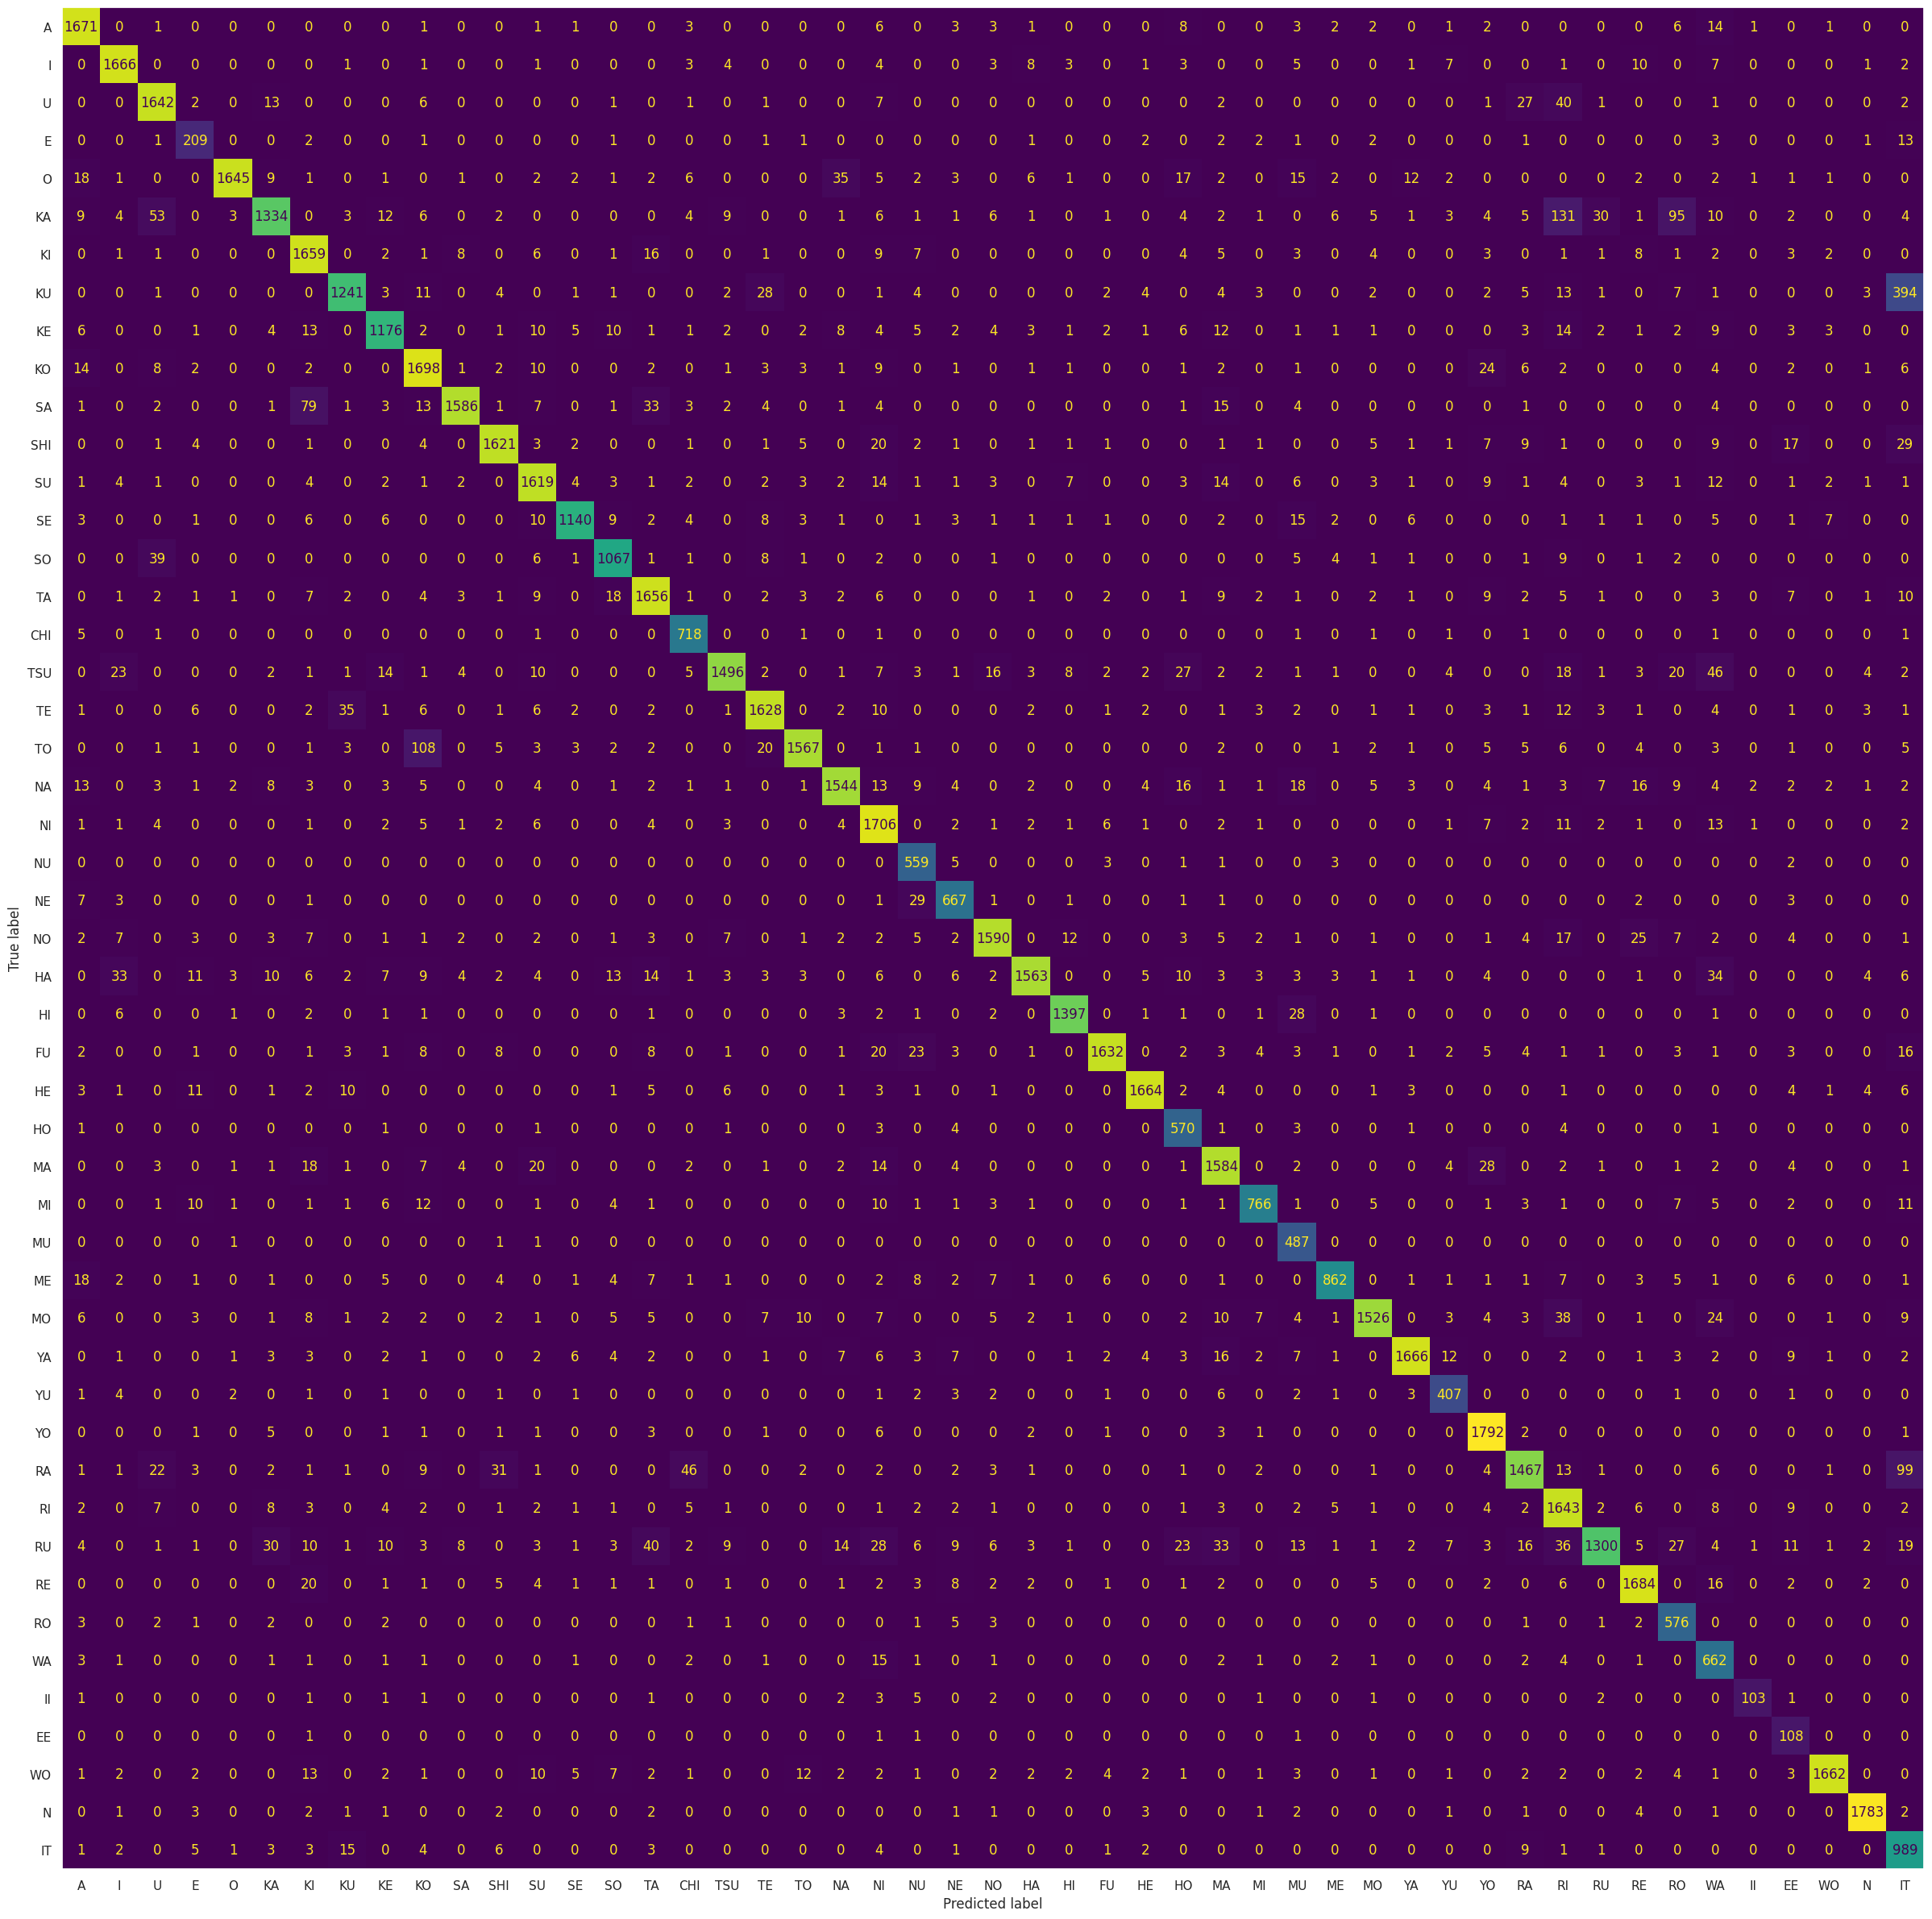

In [31]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(Y_test, y_conv2d_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [32]:
accuracy = Y_test == y_conv2d_pred
np.mean([np.mean(accuracy[Y_test == i]) for i in range(49)])

np.float64(0.9178087777989518)